# Assignment: Data Explanation and Wrangling

**Student Names:** \[Aubrey McCombs\, Ruth Oke, Naimah Muhammed, Trishma Garcon, Maiya Russell, Noelle Crawford]
**Student IDs:** \[@03012941\, @03062957, @04002311, @03100799, @04010818, @04009625]
**Course:** MATH 014\-04 \- Introduction to Data Science
**Date Created:** April 7, 2026

## **Part 1**

---



## Task 1 — Dataset Information



# Purpose and Introduction

The dataset used for this project is an NBA game performance dataset for the 2024–2025 season. It contains individual player game\-by\-game statistics such as points, rebounds, assists, field goal attempts, shooting percentages, and Game Score. As a group we're analying the trade-off between scoring volume and shooting efficiency. 

The dataset appears to track player performances across teams and opponents for regular season games. This type of data is useful in sports analytics because it helps identify player productivity, team patterns, efficiency, and performance trends over time.

This dataset is valuable in a real\-world context because NBA analysts, coaches, media, and fans use this type of information to evaluate players, compare teams, and support data\-driven decisions. Let's find out if the league's highest scoers mantan high efficiency, or does their shooting percentage drop as they take more shots.

**Source:** This dataset was obtained from Kaggle and contains NBA player game statistics for the 2024–2025 season.  
Link: https://www.kaggle.com/datasets/eduardopalmieri/nba-player-stats-season-2425



In [1]:
import pandas as pd

df = pd.read_csv("database_24_25.csv")

## Task 2 — Basic Data Exploration



In [2]:
# First 5 rows
df.head()

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,0,2,0,0,1,1,22,17.8,2024-10-22


In [3]:
# Last 5 rows
df.tail()

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
16507,Emoni Bates,CLE,WAS,W,5.18,0,2,0.0,0,2,...,0,0,2,0,0,0,2,0,-0.8,2025-02-07
16508,A.J. Green,MIL,ATL,L,20.75,1,5,0.2,0,2,...,1,1,1,0,0,0,2,2,-0.9,2025-02-07
16509,Kenrich Williams,OKC,TOR,W,16.70,0,5,0.0,0,3,...,1,3,2,0,0,1,0,0,-1.4,2025-02-07
16510,Tyrese Martin,BRK,MIA,W,20.70,1,5,0.2,0,4,...,5,5,1,0,0,3,2,2,-2.7,2025-02-07
16511,Eric Gordon,PHI,DET,L,10.35,0,4,0.0,0,3,...,3,3,2,0,0,3,1,0,-3.9,2025-02-07


In [4]:
# Shape of dataset
df.shape

(16512, 25)

In [5]:
# Column names
df.columns

Index(['Player', 'Tm', 'Opp', 'Res', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'GmSc', 'Data'],
      dtype='object')

### The dataset contains 16,512 rows and 25 columns. Each row appears to represent one player's performance in one game. The columns include player name, team, opponent, result, minutes played, shooting statistics, rebounds, assists, steals, blocks, turnovers, fouls, points, Game Score, and date.

## Task 3 — Data Types and Structure



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  16512 non-null  object 
 1   Tm      16512 non-null  object 
 2   Opp     16512 non-null  object 
 3   Res     16512 non-null  object 
 4   MP      16512 non-null  float64
 5   FG      16512 non-null  int64  
 6   FGA     16512 non-null  int64  
 7   FG%     16512 non-null  float64
 8   3P      16512 non-null  int64  
 9   3PA     16512 non-null  int64  
 10  3P%     16512 non-null  float64
 11  FT      16512 non-null  int64  
 12  FTA     16512 non-null  int64  
 13  FT%     16512 non-null  float64
 14  ORB     16512 non-null  int64  
 15  DRB     16512 non-null  int64  
 16  TRB     16512 non-null  int64  
 17  AST     16512 non-null  int64  
 18  STL     16512 non-null  int64  
 19  BLK     16512 non-null  int64  
 20  TOV     16512 non-null  int64  
 21  PF      16512 non-null  int64  
 22

In [7]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
Index(['MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB',
       'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'GmSc'],
      dtype='object')

Categorical columns:
Index(['Player', 'Tm', 'Opp', 'Res', 'Data'], dtype='object')


### Most performance-stat columns are numerical, such as MP, FG, FGA, FG%, 3P, 3PA, FT, TRB, AST, STL, BLK, TOV, PF, PTS, and GmSc. Categorical columns include Player, Tm, Opp, Res, and Data. However, the Data column should be converted from object to datetime because it represents dates and will be easier to analyze in time-based trends once converted.

In [8]:
df["Data"] = pd.to_datetime(df["Data"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Player  16512 non-null  object        
 1   Tm      16512 non-null  object        
 2   Opp     16512 non-null  object        
 3   Res     16512 non-null  object        
 4   MP      16512 non-null  float64       
 5   FG      16512 non-null  int64         
 6   FGA     16512 non-null  int64         
 7   FG%     16512 non-null  float64       
 8   3P      16512 non-null  int64         
 9   3PA     16512 non-null  int64         
 10  3P%     16512 non-null  float64       
 11  FT      16512 non-null  int64         
 12  FTA     16512 non-null  int64         
 13  FT%     16512 non-null  float64       
 14  ORB     16512 non-null  int64         
 15  DRB     16512 non-null  int64         
 16  TRB     16512 non-null  int64         
 17  AST     16512 non-null  int64         
 18  STL   

## Task 4 — Descriptive Summary



In [9]:
df.describe()

,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,...,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512
mean,22.405259,3.848958,8.271742,0.427527,1.250061,3.477955,0.263719,1.572917,2.016897,0.417737,...,3.071827,4.099079,2.453852,0.769985,0.468084,1.273861,1.749152,10.520894,8.575109,2024-12-14 19:47:10.813953536
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.600000,2024-10-22 00:00:00
25%,14.427500,1.000000,4.000000,0.286000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3.000000,2.400000,2024-11-16 00:00:00
50%,23.430000,3.000000,7.000000,0.444000,1.000000,3.000000,0.250000,1.000000,1.000000,0.333000,...,2.000000,3.000000,2.000000,0.000000,0.000000,1.000000,2.000000,9.000000,7.100000,2024-12-15 00:00:00
75%,31.322500,6.000000,12.000000,0.571000,2.000000,5.000000,0.500000,2.000000,3.000000,1.000000,...,4.000000,6.000000,4.000000,1.000000,1.000000,2.000000,3.000000,16.000000,13.300000,2025-01-13 00:00:00
max,50.480000,22.000000,38.000000,1.000000,10.000000,20.000000,1.000000,18.000000,26.000000,1.000000,...,23.000000,28.000000,22.000000,8.000000,10.000000,11.000000,6.000000,60.000000,54.200000,2025-02-07 00:00:00
std,10.896645,3.255864,6.071434,0.254938,1.523651,3.151726,0.286271,2.233374,2.688863,0.435771,...,2.717525,3.478652,2.613505,0.991039,0.833377,1.428819,1.436416,8.829493,7.821577,NaN


In [10]:
df.describe(include="all")

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
count,16512,16512,16512,16512,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,...,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512
unique,562,30,30,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Jaden McDaniels,ORL,POR,L,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,52,600,586,8265,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,22.405259,3.848958,8.271742,0.427527,1.250061,3.477955,...,3.071827,4.099079,2.453852,0.769985,0.468084,1.273861,1.749152,10.520894,8.575109,2024-12-14 19:47:10.813953536
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.600000,2024-10-22 00:00:00
25%,NaN,NaN,NaN,NaN,14.427500,1.000000,4.000000,0.286000,0.000000,1.000000,...,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3.000000,2.400000,2024-11-16 00:00:00
50%,NaN,NaN,NaN,NaN,23.430000,3.000000,7.000000,0.444000,1.000000,3.000000,...,2.000000,3.000000,2.000000,0.000000,0.000000,1.000000,2.000000,9.000000,7.100000,2024-12-15 00:00:00
75%,NaN,NaN,NaN,NaN,31.322500,6.000000,12.000000,0.571000,2.000000,5.000000,...,4.000000,6.000000,4.000000,1.000000,1.000000,2.000000,3.000000,16.000000,13.300000,2025-01-13 00:00:00
max,NaN,NaN,NaN,NaN,50.480000,22.000000,38.000000,1.000000,10.000000,20.000000,...,23.000000,28.000000,22.000000,8.000000,10.000000,11.000000,6.000000,60.000000,54.200000,2025-02-07 00:00:00


### The summary statistics show that player performance varies a lot across games. For example, points, rebounds, and assists have wide ranges, which is expected because some players have much larger offensive roles than others.

### One unusual value is that the minimum for minutes played is 0, which suggests some players were listed in a game but did not actually log meaningful minutes. The percentage columns are stored as decimals between 0 and 1, which is consistent, but this should be kept in mind when interpreting the results.

## Task 5 — Missing or Duplicate Data



In [11]:
df.isnull().sum()

Player    0
Tm        0
Opp       0
Res       0
MP        0
FG        0
FGA       0
FG%       0
3P        0
3PA       0
3P%       0
FT        0
FTA       0
FT%       0
ORB       0
DRB       0
TRB       0
AST       0
STL       0
BLK       0
TOV       0
PF        0
PTS       0
GmSc      0
Data      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

### The dataset does not appear to have missing values in any column, and there are no duplicate rows. This is helpful because it means the dataset is already relatively clean and can be analyzed without major preprocessing. 

### Because there is no missing or duplicate data, the main data preparation focus is on improving data types and creating useful derived variables.

## Task 6 — Add a New Column



In [13]:
# Task 6 — Add new column (Points per Minute)

df["PTS_per_Min"] = df.apply(
    lambda row: row["PTS"] / row["MP"] if row["MP"] > 0 else 0,
    axis=1
)

df.head()

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data,PTS_per_Min
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,4,10,1,1,1,1,37,38.1,2024-10-22,1.221122
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,16,4,1,3,1,1,36,34.0,2024-10-22,0.957956
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,3,4,1,0,0,1,24,22.4,2024-10-22,0.901239
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,4,4,1,0,0,2,18,19.5,2024-10-22,0.589777
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,2,0,0,1,1,22,17.8,2024-10-22,0.851064


### In this task, we created a new column called `PTS_per_Min`, which represents the number of points a player scored per minute played in a game. This is a useful derived metric because it helps compare scoring efficiency across players, even when they play different numbers of minutes.

### To avoid division errors, we used a lambda function so that if a player had 0 minutes played, the value for `PTS_per_Min` would be recorded as 0.

## Task 7 — Filter the Data



In [14]:
# Filter 1: High-scoring games
high_scoring_games = df[df["PTS"] >= 30]
high_scoring_games[["Player", "Tm", "Opp", "PTS", "MP", "PTS_per_Min"]].head()

,Player,Tm,Opp,PTS,MP,PTS_per_Min
0,Jayson Tatum,BOS,NYK,37,30.30,1.221122
1,Anthony Davis,LAL,MIN,36,37.58,0.957956
42,LaMelo Ball,CHO,HOU,34,37.92,0.896624
43,Lauri Markkanen,UTA,MEM,35,34.57,1.012439
44,Trae Young,ATL,BRK,30,36.67,0.818107


In [15]:
# Filter 2: High overall performance using query()
elite_games = df.query("GmSc >= 20")
elite_games[["Player", "Tm", "Opp", "PTS", "AST", "TRB", "GmSc"]].head()

,Player,Tm,Opp,PTS,AST,TRB,GmSc
0,Jayson Tatum,BOS,NYK,37,10,4,38.1
1,Anthony Davis,LAL,MIN,36,4,16,34.0
2,Derrick White,BOS,NYK,24,4,3,22.4
42,LaMelo Ball,CHO,HOU,34,11,8,33.0
43,Lauri Markkanen,UTA,MEM,35,2,9,29.4


### For this task, we created two filtered subsets of the dataset.

### The first subset includes games where players scored at least 30 points. This is interesting because it highlights strong scoring performances.

### The second subset includes games where players had a Game Score of at least 20. This is useful because Game Score captures overall productivity, not just scoring, so it helps identify well-rounded high-impact performances.

## Task 8 — Unique Values and Categories



In [16]:
# Unique teams
print("Unique teams:")
print(df["Tm"].unique())

Unique teams:
['BOS' 'LAL' 'NYK' 'MIN' 'CHO' 'UTA' 'ATL' 'ORL' 'CLE' 'BRK' 'HOU' 'MIL'
 'NOP' 'IND' 'GSW' 'DET' 'MEM' 'PHO' 'CHI' 'TOR' 'LAC' 'MIA' 'PHI' 'POR'
 'OKC' 'DAL' 'DEN' 'WAS' 'SAC' 'SAS']


In [17]:
# Unique opponents
print("Unique opponents:")
print(df["Opp"].unique())

Unique opponents:
['NYK' 'MIN' 'BOS' 'LAL' 'HOU' 'MEM' 'BRK' 'MIA' 'TOR' 'ATL' 'CHO' 'PHI'
 'CHI' 'DET' 'POR' 'IND' 'UTA' 'LAC' 'NOP' 'CLE' 'PHO' 'ORL' 'MIL' 'GSW'
 'DEN' 'SAC' 'WAS' 'SAS' 'OKC' 'DAL']


In [18]:
# Win/loss distribution
print("Result counts:")
print(df["Res"].value_counts())

Result counts:
Res
L    8265
W    8247
Name: count, dtype: int64


In [19]:
# Number of unique players
print("Number of unique players:", df["Player"].nunique())

Number of unique players: 562


### The most important categorical variables in this dataset are `Player`, `Tm`, `Opp`, and `Res`.

- `Player` identifies the athlete being observed.
- `Tm` identifies the player’s team.
- `Opp` identifies the opponent team.
- `Res` shows whether the game was a win or loss.

### These variables are useful for grouping and comparing player performance across teams, opponents, and game outcomes.

## Task 9 — Initial Observations



### The dataset gives detailed game-by-game player statistics, which makes it possible to study both individual scoring output and overall performance. I also found it useful that the dataset includes Game Score, because it gives a broader picture of how productive a player was in a game. 

### As a group we determined you can compare "volume shooters" like Shai Gilgeous-Alexander or Anthony Edwards against "efficiency specialists" like Rudy Gobert to see who provides the most value per possession. Another interesting thing about this dataset is that you can compare "volume shooters" like Shai Gilgeous-Alexander or Anthony Edwards against "efficiency specialists" like Rudy Gobert to see who provides the most value per possession.

### During exploration, we noticed that player statistics vary widely across games, especially in points, minutes played, and Game Score. We also found that some players had 0 minutes played, which is why we added a condition when creating the `PTS_per_Min` column. Overall, this dataset seems very useful for analyzing player efficiency, comparing standout performances, and studying patterns across teams and opponents.

---

### Issues Encountered

- Some players had **0 minutes played (MP = 0)**, which caused a division by zero issue when calculating `PTS_per_Min`. This was resolved by using a conditional statement in the calculation.
- The `Data` column was originally stored as a **string**, which limits time-based analysis. It should be converted to a datetime format for better usability.
- Certain columns such as `GmSc` (Game Score) and shooting percentages (`FG%`, `3P%`, `FT%`) required additional interpretation to understand their meaning.
- Percentage values are stored as **decimals (e.g., 0.45 instead of 45%)**, which may be confusing at first when interpreting results.
- The dataset is relatively large (over 16,000 rows), making it difficult to manually inspect patterns without using filtering or summary statistics.

### Questions and Observations

- Which players are the most efficient scorers based on points per minute?
- Do players perform better when they play more minutes?
- Are there noticeable differences in performance between wins and losses?
- Which teams tend to produce the highest-performing players?
- How does player performance vary across different opponents or over time?

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("database_24_25.csv")

# optional if you didn’t already
df["Data"] = pd.to_datetime(df["Data"])

In [21]:
import seaborn as sns
print("Seaborn installed successfully")

Seaborn installed successfully



## **Part 2**

---

## Section 1 — Individual Visualizations



### Task 1



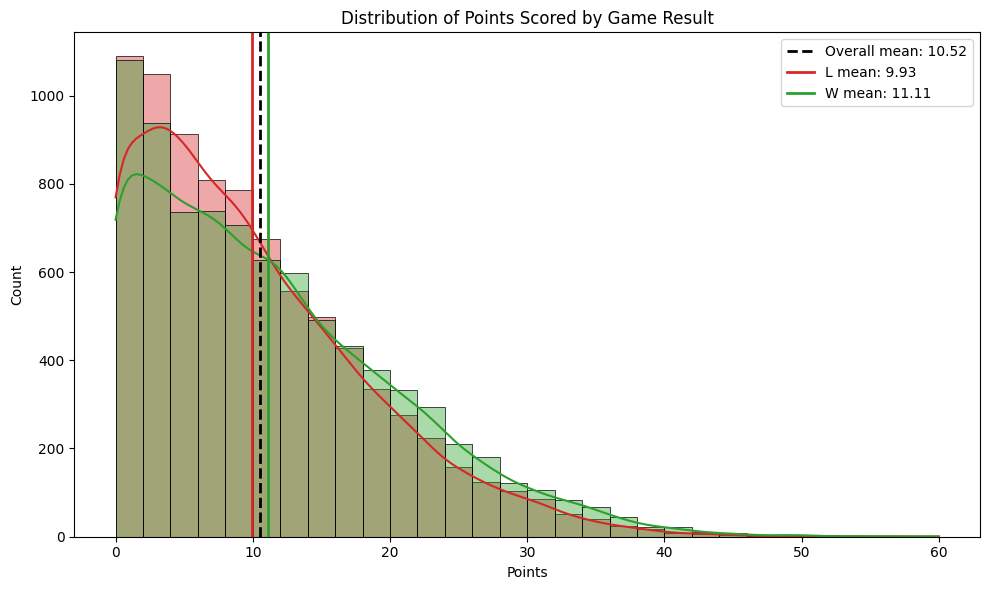

In [6]:
plt.figure(figsize=(10,6))

# Histogram of PTS colored by game result with KDE and per-group mean lines
palette = {"W": "#2ca02c", "L": "#d62728"}
ax = sns.histplot(data=df, x="PTS", hue="Res", multiple="layer", bins=30, kde=True, 
                  palette=palette, alpha=0.4, edgecolor=None)

# add subtle black edge to bars for contrast (matplotlib patches)
for p in ax.patches:
    p.set_edgecolor('black')
    p.set_linewidth(0.5)

# overall mean line
overall_mean = df["PTS"].mean()
plt.axvline(overall_mean, color='black', linestyle='--', linewidth=2, label=f"Overall mean: {overall_mean:.2f}")

# per-result mean lines (colored by result)
means = df.groupby('Res')['PTS'].mean()
for res, m in means.items():
    plt.axvline(m, color=palette.get(res, 'gray'), linestyle='-', linewidth=2, label=f"{res} mean: {m:.2f}")

plt.title("Distribution of Points Scored by Game Result")
plt.xlabel("Points")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### This histogram shows the distribution of points scored by players. Most values are concentrated in the lower to mid-range, indicating that the majority of players score relatively modest point totals in a game. 

### There are fewer high-scoring performances, which appear as a right tail, showing that games with very high points are less common.


/var/folders/09/88hb3rg148vdkydpdk6hgrn00000gn/T/ipykernel_3036/3160945234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Res", data=df, palette={"W": "#2ca02c", "L": "#d62728"}, order=["W", "L"])


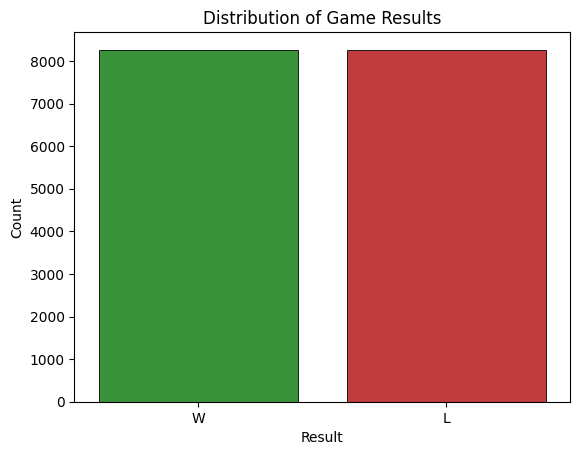

In [ ]:
# Count plot for game results with explicit two-color mapping
plt.figure()

ax = sns.countplot(x="Res", data=df, palette={"W": "#2ca02c", "L": "#d62728"}, order=["W", "L"])
# add subtle black edge to bars for contrast
for p in ax.patches:
    p.set_edgecolor('black')
    p.set_linewidth(0.6)

plt.title("Distribution of Game Results")
plt.xlabel("Result")
plt.ylabel("Count")

plt.show()

### This count plot shows the frequency of wins and losses. It helps visualize how often each outcome occurs in the dataset.

### The distribution may show whether the dataset is balanced between wins and losses or if one outcome appears more frequently.

### Task 2



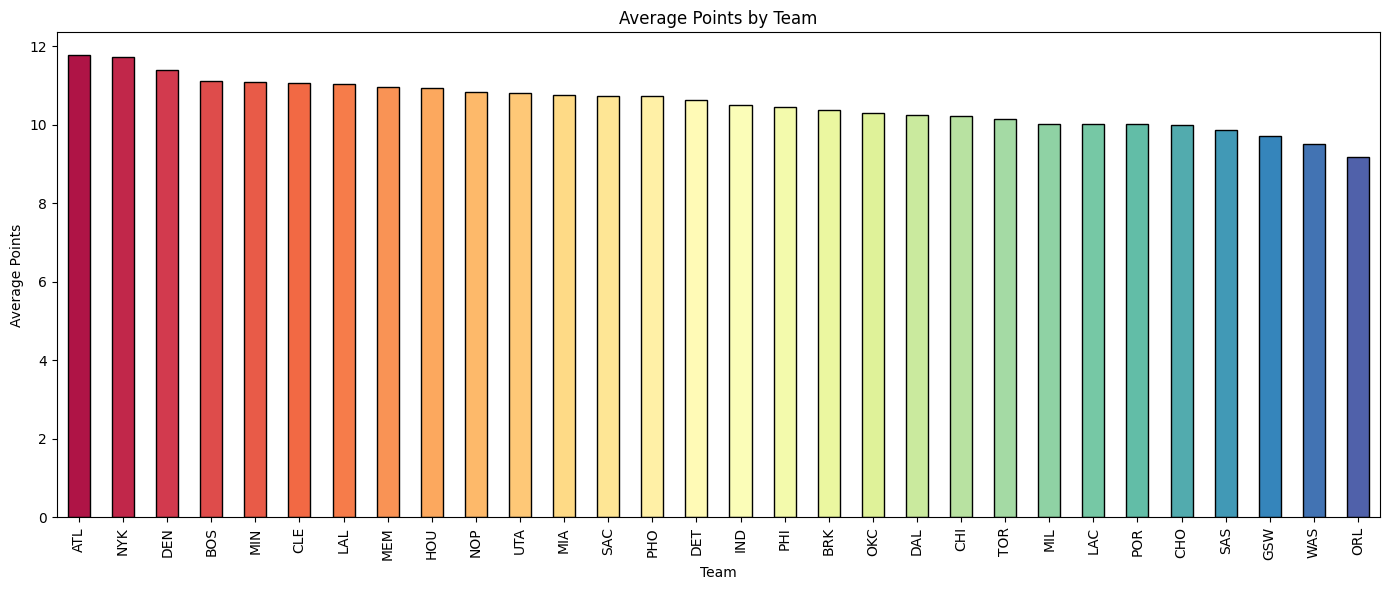

In [4]:
# Average points by team with a color palette
team_avg_pts = df.groupby("Tm")["PTS"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
# use a seaborn palette with one color per team
palette = sns.color_palette("Spectral", n_colors=len(team_avg_pts))

team_avg_pts.plot(kind="bar", color=palette, edgecolor='black')

plt.title("Average Points by Team")
plt.xlabel("Team")
plt.ylabel("Average Points")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### This bar chart compares the average points scored by players across different teams.

### Some teams show higher average scoring, which may indicate stronger offensive performance or a faster-paced style of play. Other teams have lower averages, suggesting more balanced scoring or defensive strategies.

## Section 2 — Relationship Visualizations



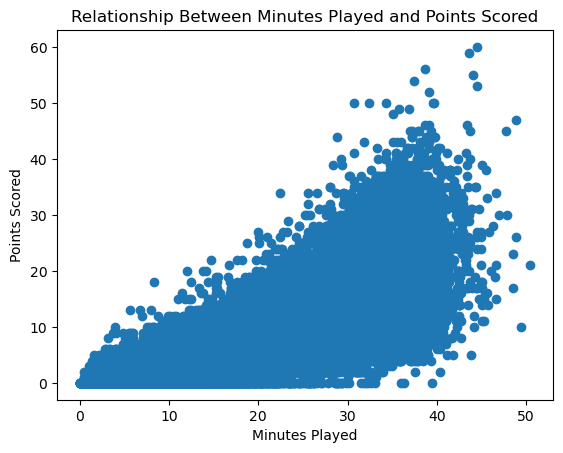

In [ ]:
plt.figure()

plt.scatter(df["MP"], df["PTS"], alpha=0.5)

# Add a line for the average points
avg_pts = df["PTS"].mean()
plt.axhline(y=avg_pts, color="red", linestyle="--", linewidth=2, label=f"Average Points: {avg_pts:.2f}")

plt.title("Relationship Between Minutes Played and Points Scored")
plt.xlabel("Minutes Played")
plt.ylabel("Points Scored")
plt.legend()

plt.show()

### This scatter plot shows the relationship between minutes played and points scored.

### There appears to be a positive relationship, meaning that players who play more minutes tend to score more points. However, the spread also shows variability, indicating that not all players score efficiently even with more playing time.

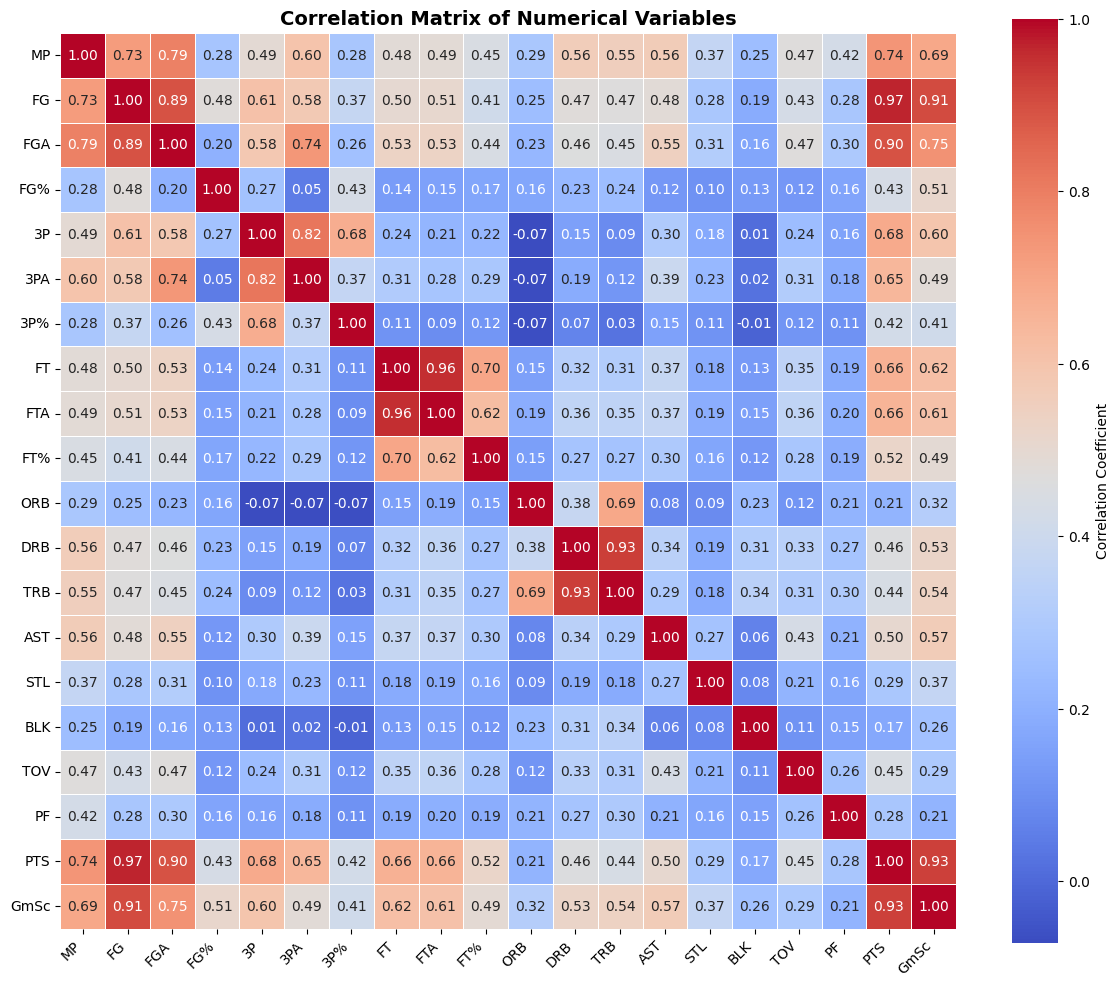

In [2]:
plt.figure(figsize=(12, 10))

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", 
            cbar_kws={"label": "Correlation Coefficient"}, square=True, linewidths=0.5)

plt.title("Correlation Matrix of Numerical Variables", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

### The heatmap shows the correlation between numerical variables in the dataset.

### Strong positive correlations can be observed between related statistics such as points, field goals, and field goal attempts. This makes sense because scoring is directly tied to shooting performance.

### Weaker or near-zero correlations suggest that some variables are not strongly related. This visualization helps identify relationships and potential predictors of performance.